# M3 Model Deep Dive: LightGBM (Light Gradient Boosting Machine)

For our third model (M3), we selected the Light Gradient Boosting Machine (LightGBM), a state-of-the-art implementation of the Gradient Boosting framework. Gradient Boosting is a powerful ensemble learning technique that builds a strong predictive model by sequentially combining a series of "weak" learners, which in this case are decision trees. LightGBM is an optimized version of this framework, designed for high speed and efficiency without sacrificing accuracy.

## The Gradient Boosting Algorithm (The Foundation)

The core idea behind Gradient Boosting is to build a model in a stage-wise fashion. It trains a sequence of decision trees, where each new tree is trained to correct the errors (or residuals) of the previous ones.

Let's denote our target variable (Claim Frequency) as $y$ and our feature set as $X$. The algorithm proceeds as follows:

1. **Initialize the model with a constant value**: The first model, $F_0(x)$, is a simple prediction, typically the mean of the target variable.

$$F_0(x) = \bar{y}$$

2. **Iterate to build trees** (for m = 1 to M): For each of the $M$ trees we want to build:

   a. **Compute the residuals (pseudo-residuals)**: Calculate the errors from the current ensemble model $F_{m-1}(x)$. For regression with Mean Squared Error (MSE), these are simply the negative gradients of the loss function.

   $$r_{im} = y_i - F_{m-1}(x_i) \quad \text{for } i=1, \dots, n$$

   b. **Fit a new weak learner (a decision tree)**: A new decision tree, $h_m(x)$, is trained on the input features $X$ but uses the residuals $r_m$ as the target variable. The goal of this tree is to learn the errors of the current ensemble.

   c. **Update the ensemble model**: The new tree's predictions are added to the overall model, scaled by a learning rate $\nu$ (also known as shrinkage). The learning rate controls how much each tree contributes to the final model, which helps prevent overfitting.

   $$F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x)$$

3. **Final Prediction**: The final prediction for a new data point is the output of the last model, $F_M(x)$.

## Mathematical Formulation of Gradient Boosting

The algorithm is framed as a gradient descent optimization in function space. The objective is to minimize a loss function $L(y, F(x))$. For a regression task using Mean Squared Error (MSE), the loss function for a single prediction is:

$$L(y_i, F(x_i)) = \frac{1}{2}(y_i - F(x_i))^2$$

The negative gradient (or "pseudo-residual") of this loss function with respect to the model's prediction $F(x_i)$ is:

$$r_{im} = - \left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F(x) = F_{m-1}(x)} = y_i - F_{m-1}(x_i)$$

This is precisely the residual error. Each new tree $h_m(x)$ is trained to approximate this negative gradient. The model is then updated by taking a step in the direction of this negative gradient, scaled by the learning rate $\nu$.

## What Makes LightGBM "Light" and Efficient?

LightGBM introduces two main innovations over traditional Gradient Boosting implementations to achieve its speed and efficiency:

### 1. Histogram-Based Algorithm

Traditional GBMs iterate through every single data point for every feature to find the best split, which is computationally very expensive (O(data × features)). LightGBM instead discretizes continuous feature values into a fixed number of bins (like a histogram). It then finds the optimal split point among the bin boundaries instead of all the data points. This significantly reduces the computational cost and memory usage.

### 2. Leaf-wise Tree Growth

Most GBMs grow trees level-wise—they split all leaves at the current level before moving to the next, resulting in a balanced but potentially suboptimal tree. LightGBM grows leaf-wise (as shown below). It scans all the current leaves and splits the one that will result in the largest reduction in loss. This creates deeper, more specialized trees, which allows the model to converge to a good solution much faster. However, this can lead to overfitting on smaller datasets if not controlled, which is why the `num_leaves` hyperparameter is the main regularizer for this strategy.

![Level-wise vs Leaf-wise tree growth](image-placeholder.png)
*Figure: Level-wise (left) vs. Leaf-wise (right) tree growth. LightGBM uses the more efficient leaf-wise approach.

By combining these techniques, LightGBM can train models significantly faster than its predecessors, making it an ideal choice for M3, where we want to apply a state-of-the-art model to compare with our from-scratch implementations.

In [20]:
# --- 1. Import All Libraries Here ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

In [35]:
# --- 2. Data Loading and Preparation ---
# This assumes you have already run a cleaning script to create a 'ClaimFrequency' target
# and handle outliers, rare categories, etc., as discussed.

try:
    # Load your pre-cleaned training and test data
    df_train = pd.read_csv("Data/claims_train_with_freq_filtered.csv")
    df_test = pd.read_csv("Data/claims_test_with_freq_filtered.csv")
except FileNotFoundError:
    print("Cleaned data files not found. Please run your data cleaning script first.")
    # As a fallback for demonstration, we will create the target variable here.
    # In your project, you should do this in a separate cleaning script.
    df_train_raw = pd.read_csv("Data/claims_train.csv")
    df_test_raw = pd.read_csv("Data/claims_test.csv")
    df_train = df_train_raw[df_train_raw['Exposure'] <= 1].copy()
    df_test = df_test_raw[df_test_raw['Exposure'] <= 1].copy()
    df_train['ClaimFrequency'] = np.where(df_train['Exposure'] > 0, df_train['ClaimNb'] / df_train['Exposure'], 0)
    df_test['ClaimFrequency'] = np.where(df_test['Exposure'] > 0, df_test['ClaimNb'] / df_test['Exposure'], 0)
    df_train = df_train.drop(columns=['IDPol', 'ClaimNb'])
    df_test = df_test.drop(columns=['IDPol', 'ClaimNb'])


# Separate features (X) and the target variable (y)
X_train = df_train.drop("ClaimFrequency", axis=1)
y_train = df_train["ClaimFrequency"]
X_test = df_test.drop("ClaimFrequency", axis=1)
y_test = df_test["ClaimFrequency"]

# DEBUG: Check column names
print("\n=== DEBUG: Checking column names ===")
print(f"X_train columns: {X_train.columns.tolist()}")
print(f"X_test columns: {X_test.columns.tolist()}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Are columns the same? {X_train.columns.tolist() == X_test.columns.tolist()}")


=== DEBUG: Checking column names ===
X_train columns: ['ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region']
X_test columns: ['ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region']
X_train shape: (541416, 11)
X_test shape: (135373, 11)
Are columns the same? True


In [22]:
# --- 3. Building the Preprocessing Pipeline ---
# This is the same preprocessor as in your M1 model.
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('one_hot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, make_column_selector(dtype_include=np.number)),
    ('categorical', categorical_pipeline, make_column_selector(dtype_include=object))
])

In [23]:
# --- 4. Full Model Pipeline with LightGBM and Hyperparameter Tuning ---
# Reference: Chapter 7 of "Hands-On Machine Learning" for ensemble methods like Gradient Boosting.
# This is the normal version without running on an nvidia GPU:
# full_pipeline_lgb = Pipeline([
#     ('preprocessor', preprocessor),
#     ('regressor', lgb.LGBMRegressor(random_state=42))
# ])
full_pipeline_lgb = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', lgb.LGBMRegressor(
        random_state=42,
        device='gpu',
        gpu_platform_id=0,
        gpu_device_id=0
    ))
])

param_grid_lgb = {
    'regressor__n_estimators': [100, 200],  # Reduced from [200, 500, 800]
    'regressor__learning_rate': [0.1, 0.2],  # Higher learning rates = faster convergence
    'regressor__num_leaves': [31, 63],       # Reduced from [31, 63, 127]
    'regressor__max_bin': [128],             # Reduced from 255
    'regressor__min_data_in_leaf': [20, 30]  # Slightly reduced options
}



# Use GridSearchCV to find the best combination of parameters
grid_search_lgb = GridSearchCV(full_pipeline_lgb, param_grid_lgb, cv=5,
                               scoring='neg_mean_squared_error',
                               n_jobs=-1)

print("Starting hyperparameter tuning for LightGBM (M3)...")
grid_search_lgb.fit(X_train, y_train)

# Print the best parameters and the best cross-validation RMSE
print(f"Best parameters found for LightGBM: {grid_search_lgb.best_params_}")
best_rmse_lgb = np.sqrt(-grid_search_lgb.best_score_)
print(f"Best cross-validation RMSE for LightGBM: {best_rmse_lgb:.4f}")

Starting hyperparameter tuning for LightGBM (M3)...
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 561
[LightGBM] [Info] Number of data points in the train set: 541416, number of used features: 48
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4060 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 10 dense feature groups (6.20 MB) transferred to GPU in 0.008925 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 0.261601
Best parameters found for LightGBM: {'regressor__lea

In [36]:
# --- 5. Evaluating the Final LightGBM Model on the Test Set ---
# Reference: Chapter 2 of "Hands-On Machine Learning" for model evaluation.
print("\nEvaluating the best LightGBM model on the test set...")
final_lgbm_model = grid_search_lgb.best_estimator_

# Simply predict - the column names should already be correct
y_pred_lgb = final_lgbm_model.predict(X_test)

# Calculate and print all evaluation metrics
final_rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
final_mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
final_r2_lgb = r2_score(y_test, y_pred_lgb)

print(f"Final Test Set RMSE (LightGBM): {final_rmse_lgb:.4f}")
print(f"Final Test Set MAE (LightGBM): {final_mae_lgb:.4f}")
print(f"Final Test Set R-squared (LightGBM): {final_r2_lgb:.4f}")


Evaluating the best LightGBM model on the test set...
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
Final Test Set RMSE (LightGBM): 0.8416
Final Test Set MAE (LightGBM): 0.0103
Final Test Set R-squared (LightGBM): 0.9739


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Displaying feature importances from the LightGBM model...


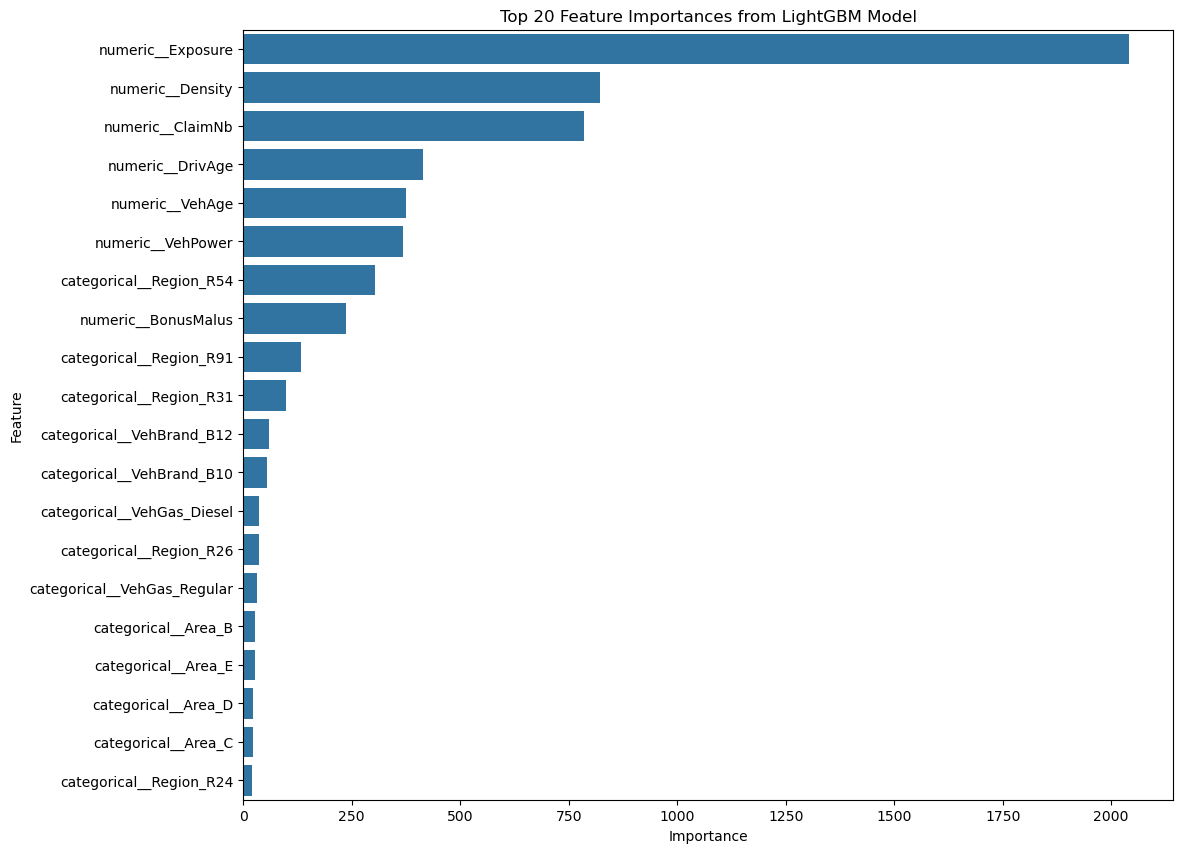

In [29]:
# --- 6. Visualizing Feature Importance from LightGBM ---
# Reference: Chapter 7 of "Hands-On Machine Learning" for feature importance.
print("\nDisplaying feature importances from the LightGBM model...")

# Get feature names from the preprocessor
feature_names_lgb = final_lgbm_model.named_steps['preprocessor'].get_feature_names_out()

# Get importances from the trained LightGBM regressor
importances_lgb = final_lgbm_model.named_steps['regressor'].feature_importances_

# Create a pandas Series for easy plotting
feature_importance_series_lgb = pd.Series(importances_lgb, index=feature_names_lgb).sort_values(ascending=False)

# Plot the top 20 features
plt.figure(figsize=(12, 10))
sns.barplot(x=feature_importance_series_lgb.head(20), y=feature_importance_series_lgb.head(20).index)
plt.title("Top 20 Feature Importances from LightGBM Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

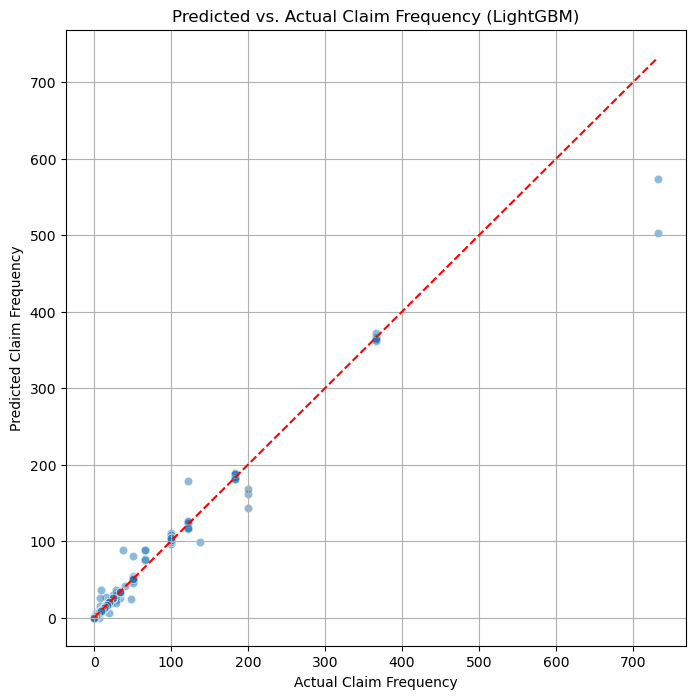

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming y_pred_lgb and y_test are from your M3 regression model
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred_lgb, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--') # Perfect prediction line
plt.xlabel("Actual Claim Frequency")
plt.ylabel("Predicted Claim Frequency")
plt.title("Predicted vs. Actual Claim Frequency (LightGBM)")
plt.grid(True)
plt.show()

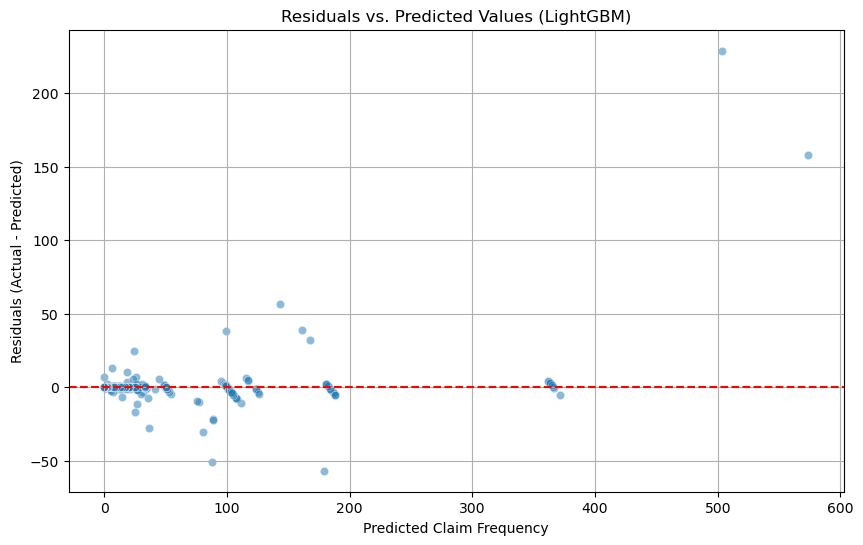

In [32]:
residuals = y_test - y_pred_lgb

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_lgb, y=residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Claim Frequency")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs. Predicted Values (LightGBM)")
plt.grid(True)
plt.show()
#*   **How to interpret:**
#*   **Good:** The points should be randomly and evenly scattered around the horizontal line at `y=0`.
#*   **Bad:** If you see a pattern (e.g., a curve or a funnel shape), it suggests your model is failing to capture some information in the data. A funnel shape (where errors get larger as the prediction increases) indicates **heteroscedasticity**, which is common in claims data.